#Challenge TelecomX Parte 2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Extracción de datos

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
ruta_datos = '/content/drive/MyDrive/Challenge_TelecomX_2/datos_telecomx_limpios.csv'

datos = pd.read_csv(ruta_datos)

In [4]:
datos.sample(10)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Daily_Value_Historical
5568,7854-FOKSF,1,Male,0,0,0,1,0,0,DSL,...,0,0,0,1,Month-to-month,0,Electronic check,35.90,35.90,1.180921
3368,4811-JBUVU,0,Male,0,0,0,30,1,1,Fiber optic,...,0,1,0,1,Month-to-month,1,Credit card (automatic),89.90,2723.15,2.957237
326,0485-ZBSLN,0,Male,0,1,1,65,1,1,No,...,0,0,0,0,Two year,0,Credit card (automatic),24.75,1715.10,0.814145
6720,9560-ARGQJ,1,Female,0,0,1,16,1,0,Fiber optic,...,0,0,1,0,Month-to-month,1,Electronic check,81.00,1312.15,2.664474
1185,1746-TGTWV,0,Male,0,1,0,1,1,0,Fiber optic,...,1,0,0,0,Month-to-month,0,Credit card (automatic),75.35,75.35,2.478618
5257,7426-GSWPO,0,Male,1,0,0,64,1,1,Fiber optic,...,0,0,1,1,Month-to-month,1,Bank transfer (automatic),103.50,6548.65,3.404605
2233,3197-NNYNB,0,Male,0,0,0,65,1,1,Fiber optic,...,1,0,1,1,Two year,0,Credit card (automatic),105.10,6631.85,3.457237
4696,6630-UJZMY,0,Female,1,1,0,4,1,1,Fiber optic,...,0,0,1,0,Month-to-month,1,Electronic check,83.25,308.05,2.738487
922,1338-CECEE,0,Male,0,1,1,41,1,1,DSL,...,1,0,1,0,One year,0,Bank transfer (automatic),68.50,2839.95,2.253289
3991,5644-PDMZC,1,Female,1,0,0,2,1,1,Fiber optic,...,0,0,0,1,Month-to-month,0,Electronic check,89.50,161.50,2.944079


##Eliminación de Columnas Irrelevantes

- Eliminé la columna `ClienID`, ya que resulta irrelevante para el entrenamiento del modelo
- La columna `Daily_Value_Historical`, al derivarse directamente de `account.Charges.Monthly` podría ser eliminada, más adelante evaluaré su permanencia para evitar redundancia entre variables.

In [5]:
datos = datos.drop(columns=["customerID"])

In [6]:
datos.sample(5)

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Daily_Value_Historical
3440,0,Male,0,0,0,63,1,1,DSL,1,...,1,1,0,0,One year,0,Electronic check,71.50,4576.30,2.351974
3886,1,Female,0,1,0,24,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Credit card (automatic),99.30,2431.35,3.266447
883,0,Male,1,0,0,70,0,0,DSL,0,...,1,0,1,0,One year,1,Credit card (automatic),44.05,3011.65,1.449013
4550,0,Female,0,1,1,24,1,1,DSL,1,...,1,0,1,1,Two year,0,Credit card (automatic),78.60,1846.65,2.585526
6681,0,Male,0,0,0,13,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.15,931.75,2.307566


##Encoding

In [7]:
#Datos categoricos, que necesitan encoding
categorical_cols = [
    "customer.gender",
    "internet.InternetService",
    "account.Contract",
    "account.PaymentMethod"
]

In [8]:
data_encoded = pd.get_dummies(datos, columns=categorical_cols, drop_first=True)

In [9]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 25 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Churn                                          7032 non-null   int64  
 1   customer.SeniorCitizen                         7032 non-null   int64  
 2   customer.Partner                               7032 non-null   int64  
 3   customer.Dependents                            7032 non-null   int64  
 4   customer.tenure                                7032 non-null   int64  
 5   phone.PhoneService                             7032 non-null   int64  
 6   phone.MultipleLines                            7032 non-null   int64  
 7   internet.OnlineSecurity                        7032 non-null   int64  
 8   internet.OnlineBackup                          7032 non-null   int64  
 9   internet.DeviceProtection                      7032 

Algunas columnas quedaron como booleanas y realmente no son numéricas. El mdelo no debería tener problemas con eso, pero por mayor seguridad las transfomaré

In [10]:
bool_cols = data_encoded.select_dtypes(include='bool').columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)

In [11]:
data_encoded.sample(5)

,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,...,account.Charges.Total,Daily_Value_Historical,customer.gender_Male,internet.InternetService_Fiber optic,internet.InternetService_No,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
6507,1,0,0,0,5,1,1,0,0,0,...,413.65,2.485197,0,1,0,0,0,0,1,0
6191,0,1,1,0,1,1,1,0,0,0,...,74.30,2.444079,1,1,0,0,0,0,1,0
4461,1,0,0,0,3,1,0,0,1,0,...,130.10,1.641447,1,0,0,0,0,0,0,1
2799,1,1,1,0,37,1,1,0,0,0,...,3473.40,3.042763,1,1,0,0,0,0,1,0
6579,0,0,0,0,4,1,0,0,0,0,...,73.05,0.680921,1,0,1,0,0,0,0,1


##Verificación de la Proporción de Cancelación (Churn)

Analicé la distribución de la variable objetivo `Churn` para verificar si existía desbalance entre las clases. Pude observar que el 73.42% de los clientes permanecen activos, mientras que el 26.58% cancelaron el servicio.
Esto indica un desbalance entre las clases, lo cual debe tenerse en cuenta al entrenar y evaluar el modelos predictivos, ya que métricas como la exactitud (accuracy) podrían resultar engañosas si el modelo favorece la clase mayoritaria.

In [12]:
churn_counts = data_encoded["Churn"].value_counts()
churn_proportions = data_encoded["Churn"].value_counts(normalize=True) * 100

In [13]:
print("Conteo de clases:")
print(churn_counts)

Conteo de clases:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [14]:
print("\nProporción de clases (%):")
print(churn_proportions)


Proporción de clases (%):
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


Text(0, 0.5, 'Número de Clientes')

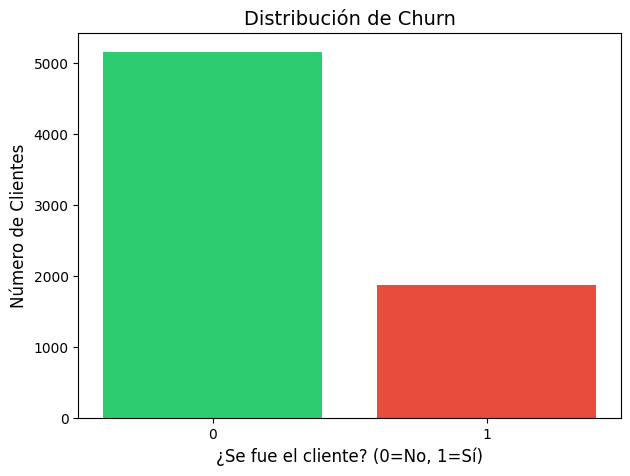

In [15]:
categorias = churn_counts.index.astype(str)
valores = churn_counts.values

colores = ['#2ecc71', '#e74c3c']
plt.figure(figsize=(7, 5))
plt.bar(categorias, valores, color=colores)

plt.title('Distribución de Churn', fontsize=14)
plt.xlabel('¿Se fue el cliente? (0=No, 1=Sí)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)

##Balanceo de Clases (Opcional)

Aunque existe un desbalance moderado entre las clases (como se vió antes). No aplicaré un balanceo en esta etapa. Primero evaluaré el rendimiento de los modelos con la distribución original, y posteriormente se podrá comparar con técnicas de balanceo si fuera necesario.

##Normalización o Estandarización
Evalué la necesidad de aplicar normalización o estandarización a las variables numéricas. Concluí que este preprocesamiento es especialmente importante en modelos sensibles a la escala de los datos, como la Regresión Logística, KNN o SVM, ya que variables con magnitudes mayores pueden influir desproporcionadamente en el entrenamiento.
En cambio, modelos basados en árboles, como Decision Tree o Random Forest, no requieren este paso, ya que no dependen de distancias ni de la escala de las variables.
Por esta razón, la estandarización se aplicará únicamente en aquellos modelos donde sea necesaria.

##Análisis de Correlación

Para esta actividad calculé la matriz de correlación para analizar la relación entre las variables numéricas y la variable objetivo `Churn`.
Entre las variables con mayor correlación positiva con la cancelación destacaron `internet.InternetService_Fiber optic`, `account.PaymentMethod_Electronic check` y `account.Charges.Monthly`, lo que sugiere una mayor propensión a churn en clientes con estas características.
Por otro lado, variables como `customer.tenure`, `account.Contract_Two year`, `internet.OnlineSecurity` y `internet.TechSupport` presentan correlación negativa, indicando que se asocian con una menor probabilidad de cancelación.

In [16]:
corr_matrix = data_encoded.corr()

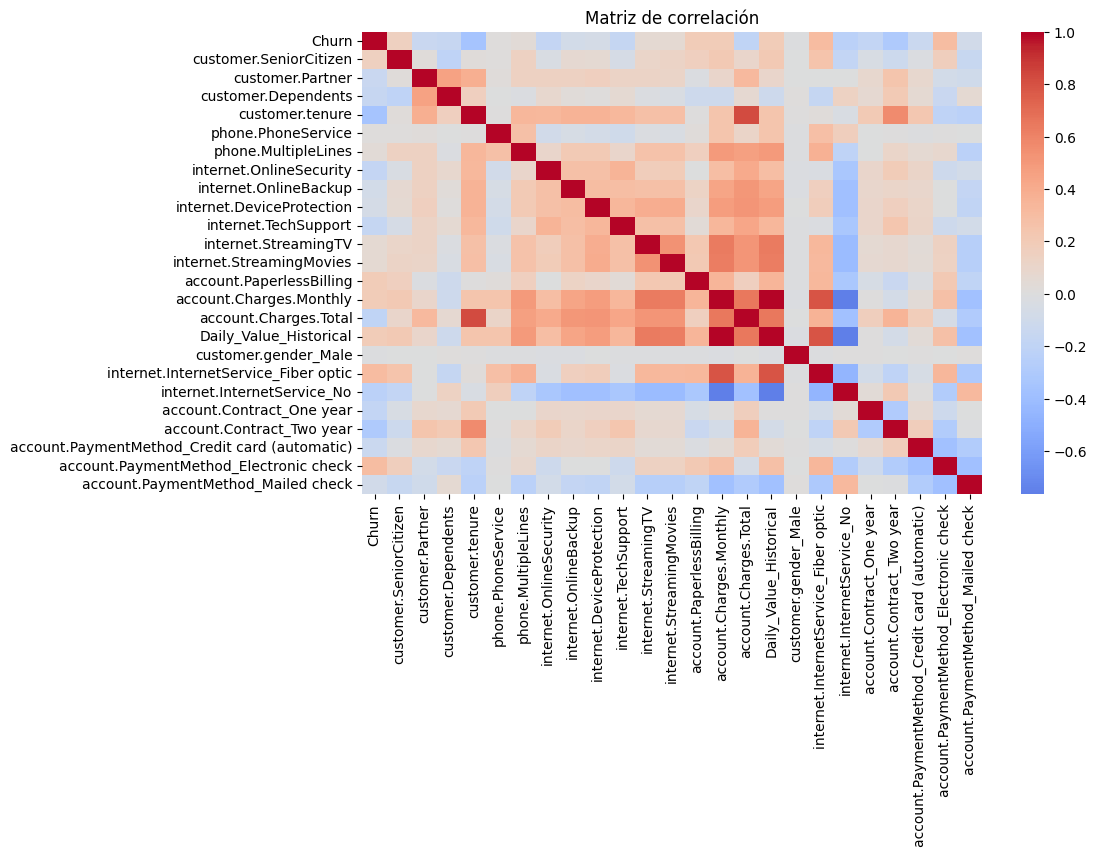

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

In [18]:
churn_corr = data_encoded.corr()["Churn"].sort_values(ascending=False)
print(churn_corr)

Churn                                            1.000000
internet.InternetService_Fiber optic             0.307463
account.PaymentMethod_Electronic check           0.301455
Daily_Value_Historical                           0.192858
account.Charges.Monthly                          0.192858
account.PaperlessBilling                         0.191454
customer.SeniorCitizen                           0.150541
internet.StreamingTV                             0.063254
internet.StreamingMovies                         0.060860
phone.MultipleLines                              0.040033
phone.PhoneService                               0.011691
customer.gender_Male                            -0.008545
internet.DeviceProtection                       -0.066193
internet.OnlineBackup                           -0.082307
account.PaymentMethod_Mailed check              -0.090773
account.PaymentMethod_Credit card (automatic)   -0.134687
customer.Partner                                -0.149982
customer.Depen

Identifiqué una correlación prácticamente perfecta entre `account.Charges.Monthly` y `Daily_Value_Historical`, lo que indica redundancia entre ambas variables. Esto sugiere que podría eliminar una de ellas para evitar duplicidad de información.

##Análisis Dirigido

###Tenure vs Churn

Al analizar la relación entre el tiempo de permanencia (`customer.tenure`) y la cancelación, se observa que los clientes que cancelaron presentan, en general, una antigüedad mucho menor que aquellos que permanecen activos. La mediana de permanencia de los clientes que cancelaron es notablemente inferior, lo que sugiere que el riesgo de churn es mayor en las primeras etapas de la relación con la empresa.

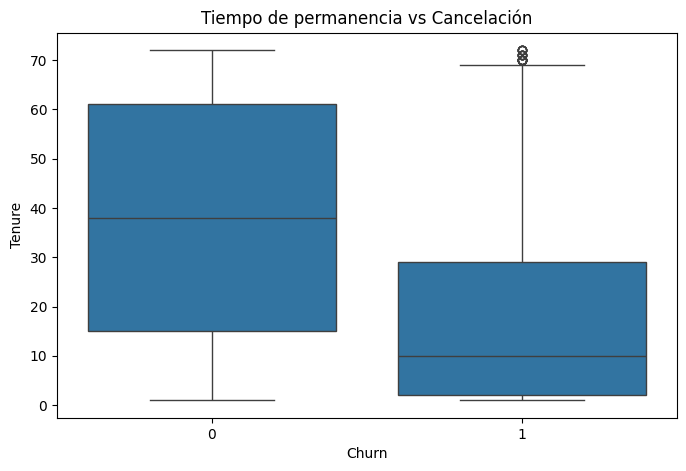

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="customer.tenure", data=data_encoded)
plt.title("Tiempo de permanencia vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

###Gasto total vs Churn

En el caso del gasto total acumulado (`account.Charges.Total`), los clientes que cancelaron muestran valores menores en comparación con los clientes que permanecen. Esto puede estar asociado a una menor antigüedad, ya que los clientes con menos tiempo en la compañía han acumulado menos cargos totales

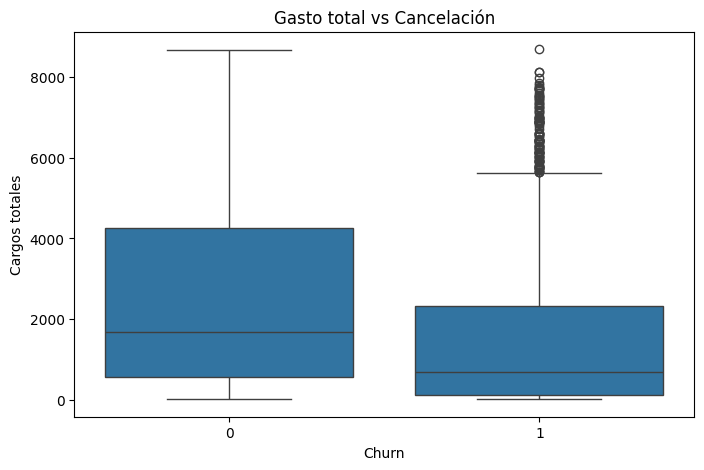

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="account.Charges.Total", data=data_encoded)
plt.title("Gasto total vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Cargos totales")
plt.show()

##Separación de Datos

Dividí el conjunto de datos en entrenamiento y prueba utilizando una proporción de 70% y 30%, respectivamente. Esta separación me permitió entrenar los modelos con una parte de los datos y evaluar su capacidad de generalización sobre observaciones no vistas. Además, se utilicé el parámetro `stratify=y` para preservar la proporción de la variable objetivo Churn en ambos subconjuntos, lo cual es especialmente importante debido al desbalance moderado identificado previamente.

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X = data_encoded.drop(columns=["Churn"])
y = data_encoded["Churn"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [24]:
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (4922, 24)
Tamaño de X_test: (2110, 24)
Tamaño de y_train: (4922,)
Tamaño de y_test: (2110,)


Verificando proporciones

In [25]:
print("Proporción en y original:")
print(y.value_counts(normalize=True))

print("\nProporción en y_train:")
print(y_train.value_counts(normalize=True))

print("\nProporción en y_test:")
print(y_test.value_counts(normalize=True))

Proporción en y original:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

Proporción en y_train:
Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Proporción en y_test:
Churn
0    0.734123
1    0.265877
Name: proportion, dtype: float64


##Creación de Modelos

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [27]:
# Variables predictoras y objetivo
X = data_encoded.drop(columns=["Churn", "Daily_Value_Historical"])
y = data_encoded["Churn"]

In [28]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [29]:
# Columnas continuas para escalar en Regresión Logística
continuous_cols = [
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total"
]

In [30]:
# Copias para modelo con escalado
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

Seleccioné la Regresión Logística como primer modelo por ser un algoritmo clásico de clasificación, interpretable y adecuado como línea base. Dado que este modelo es sensible a la escala de las variables, si apliqué estandarización a las variables numéricas continuas para evitar que aquellas con mayor magnitud influyan desproporcionadamente en el entrenamiento.

In [31]:
# Modelo 1: Regresión Logística
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Como segundo modelo se utilicé Random Forest, un algoritmo basado en árboles que no depende de la escala de las variables. Por esta razón, se entrenó directamente con los datos sin normalización. Este modelo también permite capturar relaciones no lineales y suele ofrecer buen desempeño en problemas de clasificación.

In [32]:
# Modelo 2: Random Forest
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=None
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

##Evaluación de Modelos

Evalué dos modelos de clasificación para predecir la cancelación de clientes: Regresión Logística y Random Forest.
La Regresión Logística obtuvo mejores resultados en el conjunto de prueba, con una exactitud de `80.33%`, precisión de `65.94%`, recall de `53.83%` y F1-score de `59.27%`.
Por su parte, Random Forest alcanzó una exactitud de `78.25%`, precisión de `61.86%`, recall de `47.42%` y F1-score de 53.68%.
En términos comparativos, la Regresión Logística mostró mejor capacidad para generalizar y detectar clientes con cancelación.

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predicciones
y_pred_log = log_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

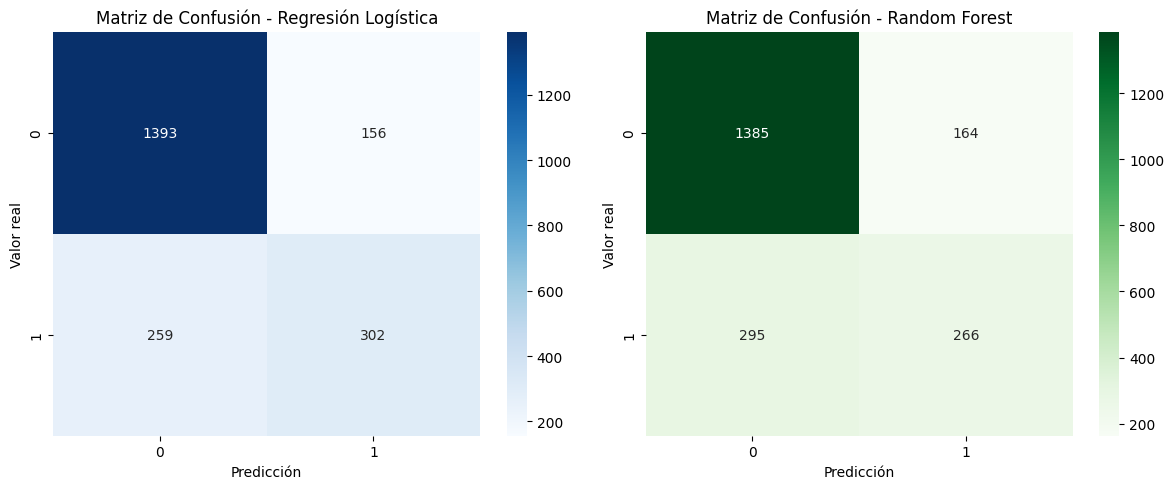

In [34]:
#Cálculo de métricas

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Matrices de confusión
cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de Confusión - Regresión Logística")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor real")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Matriz de Confusión - Random Forest")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Valor real")

plt.tight_layout()
plt.show()

In [35]:
#Detalle de las métricas

metricas = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

metricas.set_index("Modelo").round(4)

,Accuracy,Precision,Recall,F1-score
Modelo,,,,
Regresión Logística,0.8033,0.6594,0.5383,0.5927
Random Forest,0.7825,0.6186,0.4742,0.5368


Al comparar el desempeño en entrenamiento y prueba, la Regresión Logística mostró resultados consistentes, sin señales relevantes de sobreajuste. En cambio, Random Forest alcanzó una exactitud muy alta en entrenamiento (`99.86%`) pero considerablemente menor en prueba (`78.25%`), lo que indica un caso claro de overfitting. Esto sugiere que el modelo aprendió en exceso patrones específicos del conjunto de entrenamiento y perdió capacidad de generalización.

##Análisis de importancia de variables

###Regresión logística

Entre las variables con mayor contribución positiva a churn en Regresióon Logística destacan: `internet.InternetService_Fiber optic`, `account.PaymentMethod_Electronic check` y `account.PaperlessBilling`.
En contraste, variables como `customer.tenure`, `account.Contract_Two year`, `account.Contract_One year`, `internet.TechSupport` e `internet.OnlineSecurity` presentan coeficientes negativos, lo que sugiere una asociación con menor riesgo de cancelación.

In [36]:
coeficientes = pd.Series(log_model.coef_[0], index=X_train_scaled.columns)

coef_ordenados = coeficientes.sort_values()
coef_ordenados

,0
customer.tenure,-1.355738
account.Contract_Two year,-1.222059
internet.InternetService_No,-0.824993
account.Contract_One year,-0.688758
phone.PhoneService,-0.420972
internet.TechSupport,-0.403706
internet.OnlineSecurity,-0.288009
internet.OnlineBackup,-0.137382
customer.Partner,-0.095880
account.PaymentMethod_Credit card (automatic),-0.086462


In [37]:
top_positivas = coeficientes.sort_values(ascending=False).head(10)
top_negativas = coeficientes.sort_values().head(10)

print("Variables que aumentan la probabilidad de churn:")
print(top_positivas)

print("\nVariables que reducen la probabilidad de churn:")
print(top_negativas)

Variables que aumentan la probabilidad de churn:
internet.InternetService_Fiber optic      0.819897
account.Charges.Total                     0.632311
account.PaymentMethod_Electronic check    0.390821
account.PaperlessBilling                  0.370155
internet.StreamingTV                      0.264253
customer.SeniorCitizen                    0.260137
phone.MultipleLines                       0.184008
internet.StreamingMovies                  0.169547
account.PaymentMethod_Mailed check        0.011665
internet.DeviceProtection                 0.004117
dtype: float64

Variables que reducen la probabilidad de churn:
customer.tenure                                 -1.355738
account.Contract_Two year                       -1.222059
internet.InternetService_No                     -0.824993
account.Contract_One year                       -0.688758
phone.PhoneService                              -0.420972
internet.TechSupport                            -0.403706
internet.OnlineSecurity      

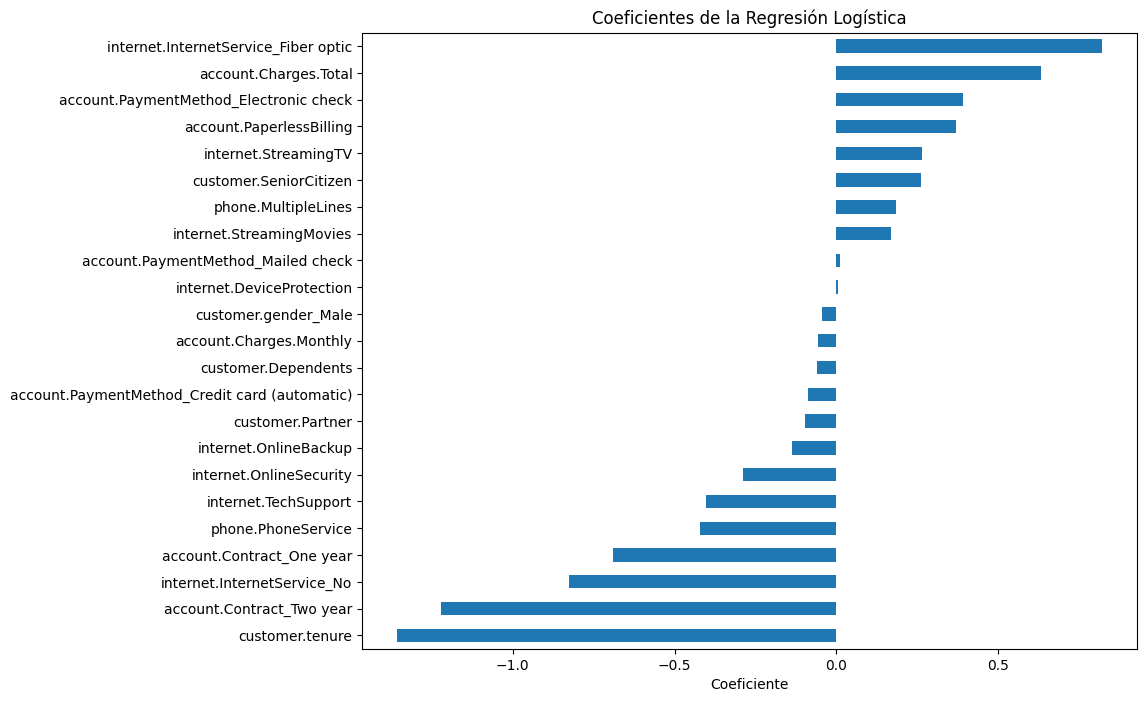

In [38]:
plt.figure(figsize=(10, 8))
coeficientes.sort_values().plot(kind="barh")
plt.title("Coeficientes de la Regresión Logística")
plt.xlabel("Coeficiente")
plt.show()

###Random Forest

El análisis en Random Forest, mostró que las variables más influyentes fueron: `account.Charges.Total`, `account.Charges.Monthly` y `customer.tenure`, seguidas por `internet.InternetService_Fiber optic` y `account.PaymentMethod_Electronic check`. Reforzando la idea de que la permanencia, el gasto y ciertas características del servicio son factores clave en la predicción de churn.

In [39]:
importancias_rf = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importancias_rf = importancias_rf.sort_values(ascending=False)

print(importancias_rf.head(15))

account.Charges.Total                     0.193174
account.Charges.Monthly                   0.177124
customer.tenure                           0.169711
internet.InternetService_Fiber optic      0.047959
account.PaymentMethod_Electronic check    0.044094
account.Contract_Two year                 0.030326
customer.gender_Male                      0.028782
account.PaperlessBilling                  0.027222
customer.Partner                          0.023659
account.Contract_One year                 0.022684
internet.TechSupport                      0.022536
internet.OnlineSecurity                   0.022483
internet.OnlineBackup                     0.022472
customer.SeniorCitizen                    0.022189
phone.MultipleLines                       0.020714
dtype: float64


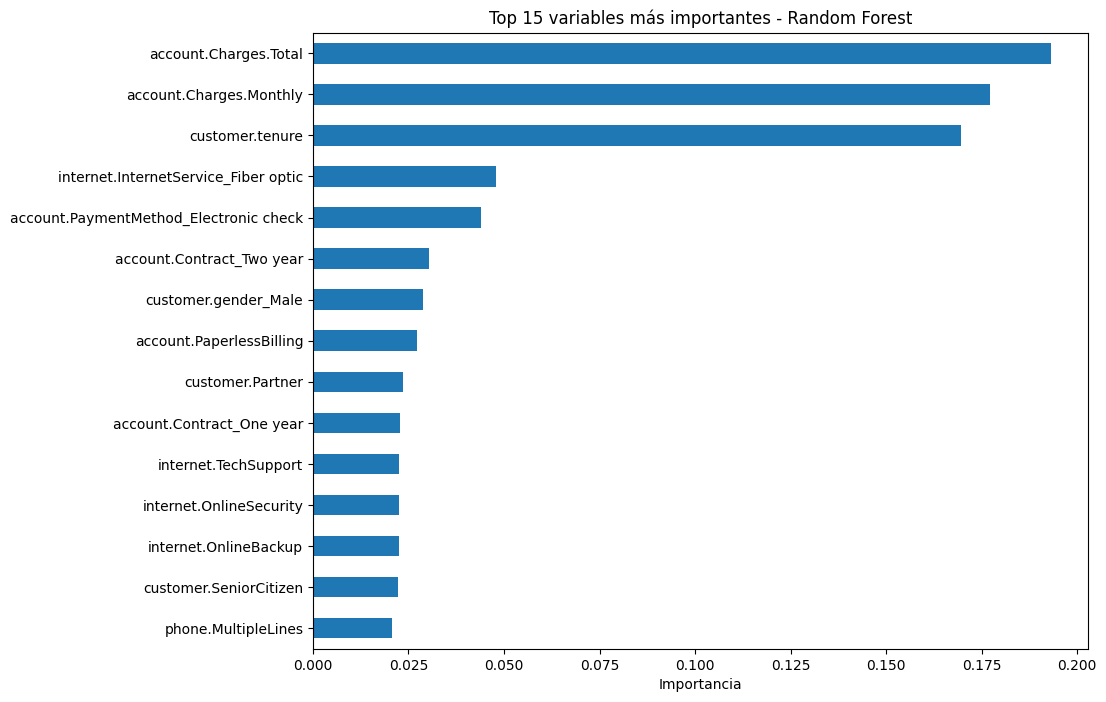

In [40]:
plt.figure(figsize=(10, 8))
importancias_rf.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.show()

La relevancia de `account.Charges.Total` debe interpretarse con cautela, ya que esta variable está relacionada con la antigüedad del cliente y sus cargos mensuales. Por ello, su importancia puede reflejar una combinación de permanencia y nivel de gasto acumulado.

##Conclusión

En este challenge se desarrolló un proceso inicial de modelado predictivo para anticipar la cancelación de clientes en la empresa Telecom X. A partir del conjunto de datos previamente tratado en el challenge anterior, se realizó la preparación para machine learning, incluyendo eliminación de variables irrelevantes, codificación de variables categóricas, revisión del desbalance de clases, análisis de correlación, análisis dirigido de variables clave y división del dataset en entrenamiento y prueba.

Se entrenaron dos modelos de clasificación: Regresión Logística y Random Forest. Tras evaluar ambos con métricas como accuracy, precision, recall, F1-score y matriz de confusión, se observó que la Regresión Logística presentó el mejor desempeño general sobre el conjunto de prueba. Además de superar a Random Forest en las métricas principales, mostró un comportamiento más estable entre entrenamiento y prueba, por lo que evidenció mejor capacidad de generalización. En cambio, Random Forest presentó señales claras de overfitting, al lograr un rendimiento casi perfecto en entrenamiento pero menor en prueba.

En cuanto a los factores más influyentes en la cancelación, tanto el análisis de correlación como la interpretación de coeficientes e importancias de variables mostraron patrones consistentes. Entre los factores más asociados a una mayor probabilidad de churn destacan:

- Menor antigüedad del cliente (customer.tenure)
- Contratos de corta duración, especialmente mes a mes
- Servicio de internet por fibra óptica
- Método de pago Electronic check
- Facturación electrónica (PaperlessBilling)
- Mayores cargos mensuales

Por otro lado, las variables asociadas a una menor probabilidad de cancelación fueron:

- Mayor tiempo de permanencia en la empresa
- Contratos de uno o dos años, especialmente de dos años
- Servicios complementarios como OnlineSecurity y TechSupport
- Presencia de partner o dependientes en algunos casos

También se observó que los clientes que cancelan tienden a tener menor antigüedad y menor gasto total acumulado, lo cual sugiere que una parte importante del churn ocurre en etapas relativamente tempranas de la relación con la empresa.

###Estrategias de retención propuestas

Con base en estos hallazgos, Telecom X podría considerar acciones como las siguientes:

1. Fortalecer la retención temprana
Diseñar estrategias para clientes nuevos, especialmente durante los primeros meses, que parecen ser el periodo de mayor riesgo de cancelación.

2. Incentivar contratos de mayor duración
Ofrecer beneficios, descuentos o servicios adicionales para migrar clientes de planes mensuales a contratos de uno o dos años.

3. Monitorear clientes con fibra óptica y pago por Electronic check
Estos perfiles muestran mayor asociación con churn, por lo que conviene realizar campañas de seguimiento, satisfacción o retención más focalizadas.

4. Promover servicios de valor agregado
Servicios como soporte técnico y seguridad online parecen estar relacionados con una menor cancelación, por lo que pueden usarse como parte de estrategias de fidelización.

5. Segmentar campañas preventivas según riesgo
El modelo puede servir como base para identificar clientes con alta probabilidad de churn y priorizar acciones comerciales o de atención antes de que cancelen.

El proyecto demuestra que es posible construir un modelo predictivo útil para anticipar la cancelación de clientes y, al mismo tiempo, extraer insights accionables para el negocio. La Regresión Logística resultó ser el modelo más adecuado en esta etapa, tanto por su rendimiento como por su facilidad de interpretación. Como siguiente paso, se podría profundizar en ajuste de hiperparámetros, balanceo de clases, validación cruzada y optimización de umbrales para mejorar aún más la detección de clientes en riesgo.